In [ ]:
import torch

# Select GPU
device = torch.device("cuda")

# Set GPU random seed
random_seed = 0
torch.cuda.manual_seed(random_seed)

# Create tensor directly on GPU
tensor = torch.rand(7, 7, device=device)

# Create second tensor directly on GPU
tensor2 = torch.rand(1, 7, device=device)

# Matrix multiplication on GPU
result = torch.matmul(tensor, tensor2.T)

print("Tensor device:", tensor.device)
print("Tensor2 device:", tensor2.device)
print("Result device:", result.device)

print("Result:")
print(result)

print(result.min(),result.max(),result.sum(),result.mean(),result.argmax(),result.argmin())


Tensor device: cuda:0
Tensor2 device: cuda:0
Result device: cuda:0
Result:
tensor([[2.0534],
        [2.3578],
        [1.8793],
        [1.6912],
        [2.5042],
        [2.0659],
        [1.9022]], device='cuda:0')
tensor(1.6912, device='cuda:0') tensor(2.5042, device='cuda:0') tensor(14.4538, device='cuda:0') tensor(2.0648, device='cuda:0') tensor(4, device='cuda:0') tensor(3, device='cuda:0')


In [ ]:
new_tensor = torch.rand(1,1,1,10)
torch.random.manual_seed(7)
new_tensor2 = new_tensor.squeeze()
new_tensor2


tensor([0.5349, 0.1988, 0.6592, 0.6569, 0.2328, 0.4251, 0.2071, 0.6297, 0.3653,
        0.8513])

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
Y = weight * X + bias

train_split = int(0.8 * len(X))

X_train, Y_train = X[:train_split], Y[:train_split]
X_test,Y_test = X[train_split:], Y[train_split:]



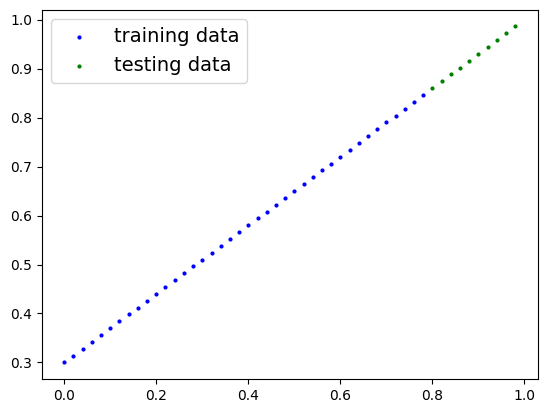

In [ ]:
def plot_predictions(train_data = X_train,
                     test_data = X_test,
                     train_labels = Y_train,
                     test_labels = Y_test,
                     predictions = None):
  plt.scatter(train_data,train_labels,c="b",s=4,label = "training data")

  plt.scatter(test_data,test_labels,c="g",s=4,label = "testing data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label = "predictions")

  plt.legend(prop={"size":14})
  plt.show()

plot_predictions()

In [ ]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.weights = nn.Parameter(torch.randn(1,
                              requires_grad=True,
                              dtype=torch.float
    ))

    self.bias = nn.Parameter(torch.randn(1,
                            requires_grad=True,
                            dtype=torch.float
    ))

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias



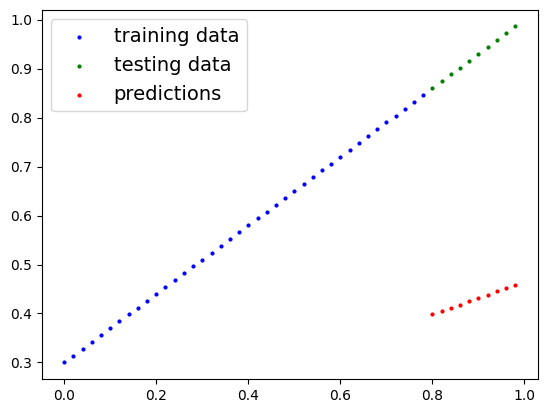

In [ ]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

#list(model_0.parameters())

with torch.inference_mode():
  y_preds = model_0(X_test)

plot_predictions(predictions=y_preds)

In [ ]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)



In [ ]:
torch.manual_seed(42)

epochs = 1000

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
  model_0.train()

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred,Y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()

  with torch.inference_mode():
    test_pred = model_0(X_test)

    test_loss = loss_fn(test_pred,Y_test.type(torch.float))

    if epoch % 100 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())

      print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}")


Epoch: 0 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 100 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 200 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 300 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 400 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 500 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 600 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 700 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 800 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882
Epoch: 900 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882


In [ ]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())#prints current state of parameters
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


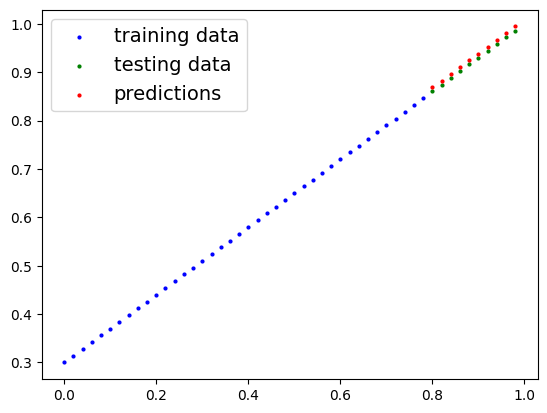

In [ ]:
model_0.eval()

with torch.inference_mode():
  y_pred = model_0(X_test)

plot_predictions(predictions=y_pred)

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>